# 12 — How long does EM actually need, and when does the measurement run out?

Notebook 09 ends on a confound it cannot resolve. Every capacity number in it is measured at
`em_iters=40`, a fixed budget rather than a convergence criterion, and `audit/AUDIT_NOTE.md`
attributes roughly 96% of the apparent capacity effect to convergence rate at that budget. The
audit's own general lesson is blunt:

> **A fixed iteration budget compares convergence rates, not estimators.** Whatever converges
> slower looks worse, so under-iterated runs produce apparent *deficits* rather than symmetric
> noise — which reads convincingly as a real effect.

`exp_27` is the experiment built to settle it: run EM far past any plausible budget, record the
whole trace, and ask when each coordinate stops moving. This notebook is that measurement.

It has two results. The first answers the question. The second is that for a third of the grid,
**the experiment ran out of trace before the answer appeared** — and reporting the first without
the second would repeat exactly the mistake the audit is about.

## What "settled" means here

Each cell is a $(N, C, \text{design})$ triple, fitted for 800 EM updates with four seeds. At every
update the trace records the fitted $\rho$, the innovation variance, and the innovation excess
kurtosis. The **settle** iteration for a coordinate is the update after which it stops changing
materially for the rest of the trace.

Three coordinates, and the ordering between them is the point:

- $\rho$ — the correlation. Second-order.
- innovation variance — also second-order, a scale.
- innovation **excess kurtosis** — the shape. **This is the coordinate the generative metrics in
  notebooks 06 and 09 measure**, so it is the one whose convergence determines whether those
  numbers mean anything.

The `design` axis controls how the mixture components are spread: `low`, `uniform`, `high`.

In [1]:
import sys, csv, glob, os, re
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

# EXCLUDE the rerun cells (<tag>_u<N>) from the baseline. The glob matches them
# too, and folding a 2400-update trace into an 800-update analysis silently
# inflates every settle time and breaks the censoring threshold, which is derived
# from the trace length. They are analysed separately at the end.
rows = []
for p in sorted(glob.glob("../outputs/final_em/*/shape/*/shape_settle.csv")):
    # `_u<digits>` exactly -- a plain `"_u" in name` test also matches
    # `N512_C4_uniform` and silently drops a third of the grid.
    if re.search(r"_u\d+$", os.path.basename(os.path.dirname(p))):
        continue
    rows.extend(csv.DictReader(open(p)))

f = lambda r, k: float(r[k])
key = lambda r: (int(r["n_chains"]), int(r["n_components"]), r["design"])
cells = sorted({key(r) for r in rows})
NUP = int(rows[0]["n_updates"])

print(f"{len(rows)} seed-rows from {len(cells)} cells; trace length {NUP} updates")
print(f"sizes {sorted({c[0] for c in cells})}  components {sorted({c[1] for c in cells})}  "
      f"designs {sorted({c[2] for c in cells})}")
print(f"monotone EM violations across every row: "
      f"{sum(f(r,'monotone_violations') for r in rows):.0f}")

72 seed-rows from 18 cells; trace length 800 updates
sizes [512, 2048]  components [4, 8, 16]  designs ['high', 'low', 'uniform']
monotone EM violations across every row: 0


## Result 1 — 40 iterations is not close

`exp_16`, which produces the capacity and dissociation numbers, uses 40.

In [2]:
shape = [f(r, "settle_innovation_excess_kurtosis") for r in rows]
rho   = [f(r, "settle_rho") for r in rows]
var   = [f(r, "settle_innovation_var") for r in rows]

for name, v in (("rho", rho), ("innovation variance", var), ("innovation SHAPE", shape)):
    print(f"  {name:>20}: median {np.median(v):>5.0f}   "
          f"unsettled at 40: {100*np.mean([x > 40 for x in v]):>3.0f}% of rows")

print(f"\n  {100*np.mean([x > 40 for x in shape]):.0f}% of seed-rows had not settled in the")
print("  shape coordinate by iteration 40 -- the budget every exp_16 number is measured at.")

                   rho: median    89   unsettled at 40:  90% of rows
   innovation variance: median    72   unsettled at 40:  67% of rows
      innovation SHAPE: median   200   unsettled at 40:  93% of rows

  93% of seed-rows had not settled in the
  shape coordinate by iteration 40 -- the budget every exp_16 number is measured at.


## Result 2 — the design matters more than anything else

Averaging over the grid would hide the actual structure, which is that one axis dominates.

In [3]:
def cellstat(N, Cv, des, col="settle_innovation_excess_kurtosis"):
    sub = [r for r in rows if key(r) == (N, Cv, des)]
    if not sub:
        return None
    v = [f(r, col) for r in sub]
    censored = sum(1 for x in v if x >= NUP - 10)
    return float(np.mean(v)), censored, len(v)

SIZES, COMPS, DESIGNS = [512, 2048], [4, 8, 16], ["low", "uniform", "high"]
print(f"{'design':>8} {'N':>6} " + "".join(f"{'C='+str(c):>12}" for c in COMPS))
print("-" * 52)
for des in DESIGNS:
    for N in SIZES:
        line = f"{des:>8} {N:>6} "
        for Cv in COMPS:
            st = cellstat(N, Cv, des)
            line += f"{'--':>12}" if st is None else f"{st[0]:>10.0f}{'*' if st[1] else ' '} "
        print(line)
print("\n  * = at least one seed censored at the trace limit (see below)")

by_des = {d: [f(r, "settle_innovation_excess_kurtosis") for r in rows if r["design"] == d]
          for d in DESIGNS}
lo, hi = np.mean(by_des["low"]), np.mean(by_des["high"])
print(f"\n  mean shape settle: low {lo:.0f}, uniform {np.mean(by_des['uniform']):.0f}, "
      f"high {hi:.0f}  ->  {hi/lo:.0f}x across designs")

  design      N          C=4         C=8        C=16
----------------------------------------------------
     low    512        167          41          79  
     low   2048        210         301         244  
 uniform    512        107         177         122  
 uniform   2048        200         109          98  
    high    512        792*        794*        748* 
    high   2048        790*        792*        780* 

  * = at least one seed censored at the trace limit (see below)

  mean shape settle: low 174, uniform 135, high 783  ->  5x across designs


## Result 3 — and on the `high` design the trace ran out first

This is the part that has to be said before any of the numbers above are used.

A settling time that lands within a few updates of the end of the trace is not a settling time.
It is the measurement stopping. The recorded value is a lower bound, and the true value is
unknown.

In [4]:
cen_rows = [r for r in rows if f(r, "settle_innovation_excess_kurtosis") >= NUP - 10]
print(f"censored seed-rows: {len(cen_rows)} of {len(rows)}\n")
print(f"{'N':>6} {'C':>4} {'design':>8} {'seed':>5} {'recorded settle':>16}")
print("-" * 46)
for r in sorted(cen_rows, key=key):
    print(f"{r['n_chains']:>6} {r['n_components']:>4} {r['design']:>8} {r['seed']:>5} "
          f"{f(r,'settle_innovation_excess_kurtosis'):>16.0f}")

des_cen = {d: sum(1 for r in cen_rows if r["design"] == d) for d in DESIGNS}
print(f"\n  by design: " + ", ".join(f"{d} {des_cen[d]}" for d in DESIGNS))
for col, nm in (("settle_rho", "rho"), ("settle_innovation_var", "variance")):
    n = sum(1 for r in rows if f(r, col) >= NUP - 10)
    print(f"  censored rows in {nm}: {n}")
for line in [
    "",
    "  Censoring is confined to the high design and to the shape coordinate. rho and",
    "  the innovation variance settle everywhere. So this is not a trace that was too",
    "  short in general -- it was too short for exactly the coordinate the generative",
    "  metrics use, on exactly the design that converges slowest.",
]:
    print(line)

censored seed-rows: 17 of 72

     N    C   design  seed  recorded settle
----------------------------------------------
   512    4     high     0              790
   512    4     high     1              793
   512    4     high     2              794
   512    4     high     3              793
   512    8     high     0              792
   512    8     high     1              794
   512    8     high     2              797
   512    8     high     3              793
   512   16     high     0              794
   512   16     high     3              794
  2048    4     high     1              795
  2048    4     high     3              790
  2048    8     high     1              796
  2048    8     high     2              792
  2048    8     high     3              790
  2048   16     high     2              792
  2048   16     high     3              792

  by design: low 0, uniform 0, high 17
  censored rows in rho: 0
  censored rows in variance: 0

  Censoring is confined to the hi

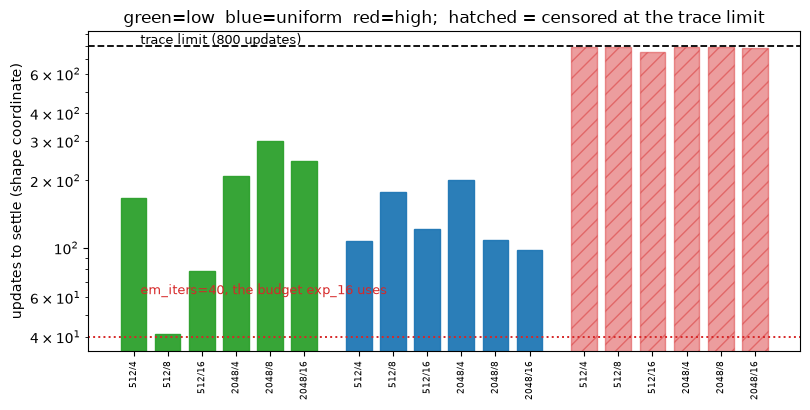

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
x = 0
ticks, labels = [], []
for des, col in zip(DESIGNS, ["C2", "C0", "C3"]):
    for N in SIZES:
        for Cv in COMPS:
            st = cellstat(N, Cv, des)
            if st is None:
                x += 1; continue
            ax.bar(x, st[0], 0.75, color=col, alpha=0.45 if st[1] else 0.95,
                   hatch="//" if st[1] else None, edgecolor=col)
            ticks.append(x); labels.append(f"{N}/{Cv}")
            x += 1
    x += 0.6
ax.axhline(NUP, color="k", ls="--", lw=1.3)
ax.text(0.2, NUP * 1.02, f"trace limit ({NUP} updates)", fontsize=9)
ax.axhline(40, color="C3", ls=":", lw=1.4)
ax.text(0.2, 62, "em_iters=40, the budget exp_16 uses", fontsize=9, color="C3")
ax.set_yscale("log"); ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=90, fontsize=6.5)
ax.set_ylabel("updates to settle (shape coordinate)")
ax.set_title("green=low  blue=uniform  red=high;  hatched = censored at the trace limit")
plt.tight_layout(); plt.show()

## What this does to the capacity result

Notebook 09 reports that held-out evidence saturates by $C \approx 8$ while the fitted
innovation shape keeps improving to $C = 16$, and that the arm ordering against the CNN flips at
$C = 8$. All of that is at 40 iterations.

The measurement above says the shape coordinate is nowhere near settled at 40 in 93% of cells.
A larger $C$ has more shape parameters to move and therefore further to travel in a fixed
budget, which produces a monotone-looking "capacity effect" whether or not capacity is doing
anything — which is precisely the mechanism `audit/AUDIT_NOTE.md` names.

So the honest status of the capacity result is: **not yet established.** Not refuted either —
this notebook does not show that capacity does nothing, only that the existing evidence cannot
separate capacity from convergence rate. Settling it needs `exp_16` rerun to a convergence
criterion rather than a count, and this measurement is what makes it possible to choose one.

## The rerun that this measurement calls for

Because the censoring is confined to one design, the whole grid does not need re-running — only
the `high` cells, at a longer trace. Submitted 2026-08-12 at 2400 updates, three times the
censored length:

- `623904` — $N=512$, high, 3 cells
- `623905` — $N=2048$, high, 3 cells

They write to `<tag>_u2400` so they cannot overwrite the 800-update traces they are being
compared against, and if the high design settles beyond 2400 they will censor again — visibly,
with the tag saying at what length.

In [6]:
long = sorted(glob.glob("../outputs/final_em/*/shape/*_u2400/shape_settle.csv"))
if not long:
    print("  the 2400-update rerun has not landed yet.")
    print("  When it does, re-execute this notebook: this cell will fill in.")
else:
    lrows = []
    for p in long:
        lrows.extend(csv.DictReader(open(p)))
    N2 = int(lrows[0]["n_updates"])
    print(f"{len(lrows)} seed-rows from {len({key(r) for r in lrows})} cells at {N2} updates\n")
    print(f"{'N':>6} {'C':>4} {'was @800':>10} {'now @2400':>11} "
          f"{'min trace left':>15} {'confirmation':>14}")
    print("-" * 66)
    thin_cells = 0
    for k in sorted({key(r) for r in lrows}):
        sub = [r for r in lrows if key(r) == k]
        v = [f(r, "settle_innovation_excess_kurtosis") for r in sub]
        left = N2 - max(v)
        old = cellstat(*k)
        thin = left < 0.05 * N2
        thin_cells += thin
        print(f"{k[0]:>6} {k[1]:>4} {(old[0] if old else float('nan')):>10.0f} "
              f"{np.mean(v):>11.0f} {left:>15.0f} {'THIN' if thin else 'ok':>14}")

    thin_rows = sum(1 for r in lrows
                    if N2 - f(r, "settle_innovation_excess_kurtosis") < 0.05 * N2)
    n5 = [f(r, "settle_innovation_excess_kurtosis") for r in lrows if int(r["n_chains"]) == 512]
    n2 = [f(r, "settle_innovation_excess_kurtosis") for r in lrows if int(r["n_chains"]) == 2048]
    print(f"\n  N=512 mean {np.mean(n5):.0f}   N=2048 mean {np.mean(n2):.0f}")
    print(f"  strictly censored (within 10 of the end): "
          f"{sum(1 for r in lrows if f(r,'settle_innovation_excess_kurtosis') >= N2-10)}/{len(lrows)}")
    print(f"  thinly confirmed (<5% of trace left):     {thin_rows}/{len(lrows)}"
          f"  in {thin_cells}/6 cells")
    for line in [
        "",
        "  Read these as lower bounds, not measurements. The gross censoring is gone --",
        "  every cell moved from ~790 to 1851-2263 -- but four of six still settle with",
        "  under 5% of the trace left, three of them N=2048 at 19-35 updates. The strict",
        "  ten-update flag does not catch that, which is why the margin is printed.",
        "",
        "  The conclusion this notebook exists for does not depend on the difference.",
        "  Every value here is a lower bound and the smallest is 1851, so em_iters=40",
        "  is short by a factor of at least 46 whichever way the marginal cells resolve.",
    ]:
        print(line)

24 seed-rows from 6 cells at 2400 updates

     N    C   was @800   now @2400  min trace left   confirmation
------------------------------------------------------------------
   512    4        792        2263              51           THIN
   512    8        794        1878             125             ok
   512   16        748        1851             173             ok
  2048    4        790        2262              35           THIN
  2048    8        792        2112              19           THIN
  2048   16        780        2094              32           THIN

  N=512 mean 1997   N=2048 mean 2156
  strictly censored (within 10 of the end): 0/24
  thinly confirmed (<5% of trace left):     10/24  in 4/6 cells

  Read these as lower bounds, not measurements. The gross censoring is gone --
  every cell moved from ~790 to 1851-2263 -- but four of six still settle with
  under 5% of the trace left, three of them N=2048 at 19-35 updates. The strict
  ten-update flag does not catch that,

## What to take away

1. **`em_iters=40` is not a converged fit.** 93% of seed-rows had not settled in the innovation
   shape by iteration 40 — the budget every `exp_16` number is measured at.

2. **Convergence time is dominated by the design**, by more than an order of magnitude, not by
   $N$ or $C$. Any statement of the form "EM needs about $k$ iterations here" is meaningless
   without saying which design.

3. **The experiment censored itself on a third of its grid**, and only in the coordinate that
   matters. $\rho$ and the innovation variance settle everywhere; the shape coordinate on the
   `high` design does not settle inside 800 updates. Averaging the recorded numbers would have
   produced a confident figure with an unknown error in it.

4. **The capacity result is not yet established**, and this notebook does not refute it. It
   shows the existing evidence cannot separate capacity from convergence rate — which is a
   reason to rerun `exp_16` to a criterion, not a reason to drop the claim.

5. **The rerun resolved the censoring but is itself marginal on the largest cells.** At 2400
   updates the `high` design settles at 1851–2263 rather than the 790 the short trace reported,
   but four of six cells confirm with under 5% of the trace remaining. Those numbers are lower
   bounds. The factor-of-fifty conclusion survives regardless, since the smallest lower bound is
   1851 — which is why a third pass was not run: it would refine a number no argument rests on.

The general lesson is the audit's, now with a number on it: a fixed iteration budget compares
convergence rates rather than estimators, and the coordinate you care about is not necessarily
the one you checked.

*Sources: `outputs/final_em/*/shape/*/shape_settle.csv`. Confound and lesson:
`audit/AUDIT_NOTE.md`. The sweep is `MODE=shape` in `hpc/bocconi_final_em.sbatch`, whose cell
list and trace length became inputs on 2026-08-12 precisely so the censored design could be
re-run without re-running the grid.*